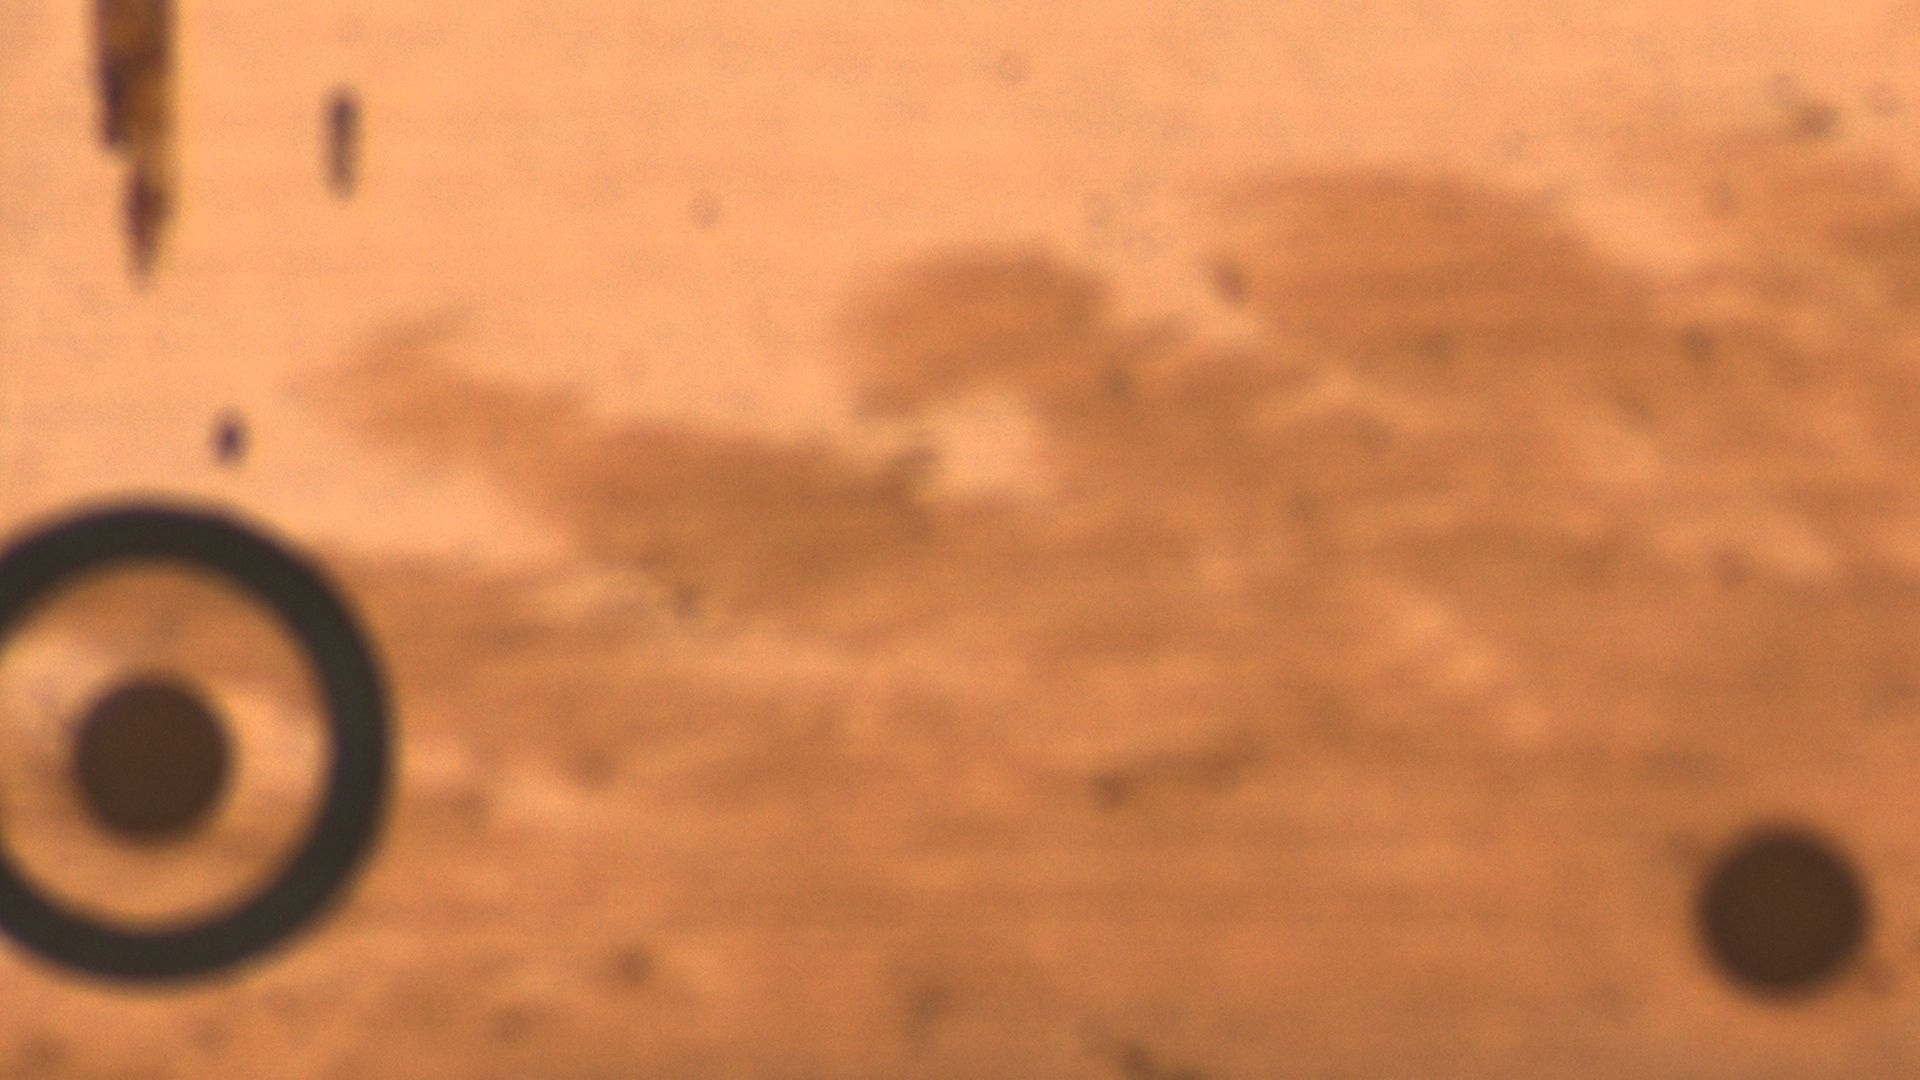

[CLIENT] Frame: 5813 | FPS: 6.3 | Size: 1920x1080
[CLIENT] Server đã đóng kết nối
[CLIENT] Đã dừng nhận stream


In [ ]:
# Cell CLIENT: Nhận stream từ WebSocket port 12345 và hiển thị
import sys
import subprocess

# Cài đặt các thư viện cần thiết
try:
    import websockets
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "websockets"])
    import websockets

try:
    import cv2
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python"])
    import cv2

import asyncio
import numpy as np
import base64
import json
from IPython.display import display, Image, clear_output
import time

client_running = False

async def receive_stream(uri="ws://localhost:12345"):
    global client_running
    print(f"[CLIENT] Đang kết nối tới {uri}...")
    
    try:
        async with websockets.connect(uri) as ws:
            print(f"[CLIENT] Đã kết nối!")
            frame_count = 0
            start_time = time.time()
            
            while client_running:
                try:
                    # Nhận message từ server
                    message = await asyncio.wait_for(ws.recv(), timeout=2.0)
                    
                    # Parse JSON chuẩn từ server
                    data = json.loads(message)
                    
                    if data["type"] == "frame":
                        # Decode base64 thành image
                        img_bytes = base64.b64decode(data["data"])
                        img_array = np.frombuffer(img_bytes, dtype=np.uint8)
                        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
                        
                        # Hiển thị trong notebook
                        _, buf = cv2.imencode('.jpg', img)
                        clear_output(wait=True)
                        display(Image(data=buf.tobytes()))
                        
                        # Thống kê
                        frame_count += 1
                        elapsed = time.time() - start_time
                        fps = frame_count / elapsed if elapsed > 0 else 0
                        print(f"[CLIENT] Frame: {frame_count} | FPS: {fps:.1f} | Size: {data['width']}x{data['height']}")
                        
                except asyncio.TimeoutError:
                    print("[CLIENT] Timeout chờ frame...")
                    continue
                except json.JSONDecodeError as e:
                    print(f"[CLIENT] Lỗi parse JSON: {e}")
                    continue
                    
    except websockets.exceptions.ConnectionClosed:
        print("[CLIENT] Server đã đóng kết nối")
    except Exception as e:
        print(f"[CLIENT] Lỗi: {e}")
    finally:
        print("[CLIENT] Đã dừng nhận stream")

def start_client(server_uri="ws://localhost:12345"):
    global client_running
    client_running = True
    
    # Chạy trong thread để không block notebook
    import threading
    
    def run_async_client():
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        try:
            loop.run_until_complete(receive_stream(server_uri))
        finally:
            loop.close()
    
    t = threading.Thread(target=run_async_client, daemon=True, name="ws-client")
    t.start()
    print("[CLIENT] Đang chạy... Để dừng: client_running = False hoặc restart kernel")

# Khởi động client - Thay IP nếu server ở máy khác
start_client("ws://localhost:12345")

In [15]:
# Cell: Test kết nối và xem stream 5 giây
print("[CLIENT] Nhấn Interrupt (■) để dừng sớm")
await receive_stream("ws://localhost:12345", duration=5)

[CLIENT] Nhấn Interrupt (■) để dừng sớm
[CLIENT] Đang kết nối tới ws://localhost:12345...
[CLIENT] Đã kết nối!
[CLIENT] Server đã đóng kết nối
[CLIENT] Đã dừng nhận stream. Tổng frames: 0
